## <span style="color:blue">  Lecture 7 - MonteCarlo sampling</span> 

### Part 1
In the NSL simulator code we have provided, include tail corrections for potential energy, $U$, and pressure $P$.

### Part 2

Use the NSL simulator code to <span style="color:red">print out **instantaneous** values of potential energy per particle, $U/N$, along **equilibrated** Monte Carlo $(N,V,T)$ and Molecular Dynamics $(N,V,E)$ simulations</span> of $M=5\times 10^5$ MC steps or MD time steps (where, for MC, the Metropolis acceptance ratio should be fixed approximately to 50% by changing the value of $dt$ that, in the MC case, represent the amplitude of the step in each direction) in the following thermodynamic conditions:
- liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r^\star_c = 2.5$, for MD $dt^\star=0.001$)

Equilibration is needed both with MC and with MD. With MD, you will observe that starting from a perfect crystalline configuration the temperature, $T$, will not conserve its value. Explore and find the starting value of $T$ needed to stabilize, after a certain number of time steps (equilibration time), the average value of $T$ on the desired $T^\star$.
<span style="color:red">Perform your MC and MD simulations by re-starting after such equilibration time.</span>

1. <span style="color:red">Once this data has been produced, compute and make pictures with a python script of the autocorrelation functions of $U/N$ to approximately estimate how large the blocks in your simulations should be.
2. Use the same data to study, with a python script, the estimation of the statistical uncertainties of the expectation value of $U/N$ for different size of the blocks in the data blocking technique, from $L=M/N=10$ to $L=5\times 10^3$, being $N$ the number of blocks. <span style="color:red">Make pictures of these statistical uncertainties as a function of $L$.</span> What you observe in the statistical uncertainties after that the block size is large enough (from the point of view of the data blocking technique)?


### Exercise 07.4

By means of your upgraded NSL simulator code, equilibrate and <span style="color:red">perform MC NVT and MD NVE simulations via a Lennard-Jones model</span> of Argon ($\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) in the following conditions:
- liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r_c = 2.5$)

show in pictures the obtained average values and uncertainties for the potential energy per particle, $U/N$, the pressure $P$ and the radial distribution function $g(r)$ in LJ units ... <span style="color:red"> and compare your MC results for these quantities with those obtained via MD NVE simulations in similar thermodynamic conditions.</span>

In [9]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib import cm
import math
viridis = plt.cm.viridis
color_MD = viridis(0.2)
color_MC = viridis(0.6)
plt.style.use('seaborn-v0_8-darkgrid')

In [10]:
def plot_thermalization(
    pot_file_MD,
    pot_file_MC,
    temp_file,
    T_ref,
    color_MD=color_MD,
    color_MC=color_MC
):

    data_pot_MD = np.loadtxt(pot_file_MD, skiprows=1)
    blocks_pot_MD, pot_MD = data_pot_MD[:, 0], data_pot_MD[:, 1]

    data_pot_MC = np.loadtxt(pot_file_MC, skiprows=1)
    blocks_pot_MC, pot_MC = data_pot_MC[:, 0], data_pot_MC[:, 1]

    data_temp = np.loadtxt(temp_file, skiprows=1)
    blocks_temp, temp = data_temp[:, 0], data_temp[:, 1]

    fig = plt.figure(figsize=(20, 6), dpi=100)

    ax0 = fig.add_subplot(1, 3, 1)
    ax1 = fig.add_subplot(1, 3, 2, sharey=ax0)
    ax2 = fig.add_subplot(1, 3, 3)

    ax0.plot(blocks_pot_MC, pot_MC, '-', color=color_MC, linewidth=0.8)
    ax0.set_xlabel('Block', fontsize=12)
    ax0.set_ylabel('Potential energy - MC simulation', fontsize=12)
    ax0.grid(True, alpha=0.6, linestyle='--')

    ax1.plot(blocks_pot_MD, pot_MD, '-', color=color_MD, linewidth=0.8)
    ax1.set_xlabel('Block', fontsize=12)
    ax1.set_ylabel('Potential energy - MD simulation', fontsize=12)
    ax1.grid(True, alpha=0.6, linestyle='--')

    ax2.plot(blocks_temp, temp, '-', color=color_MD, linewidth=0.8)
    ax2.axhline(
        y=T_ref,
        color='red',
        linewidth=0.8,
        linestyle='-.',
        label=rf'Thermalization T$^* = {T_ref}$'
    )
    ax2.set_xlabel('Block', fontsize=12)
    ax2.set_ylabel('Temperature - MD simulation', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.6, linestyle='--')

    plt.tight_layout()
    plt.show()


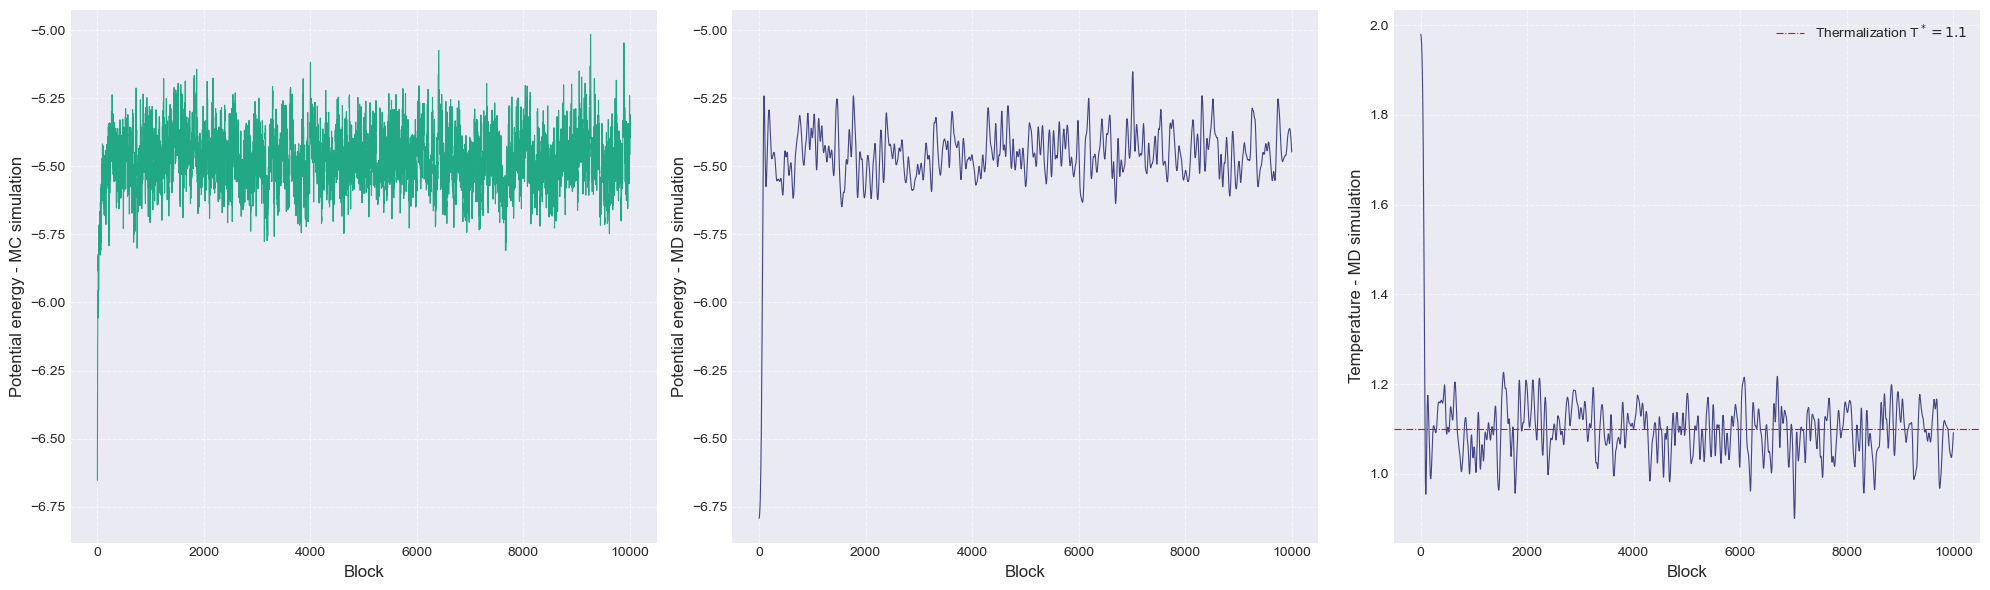

In [11]:
plot_thermalization(
    pot_file_MD='MD_CODE/OUTPUT/THERMALIZATION/potential_energy.dat',
    pot_file_MC='MC_CODE/OUTPUT/THERMALIZATION/potential_energy.dat',
    temp_file='MD_CODE/OUTPUT/THERMALIZATION/temperature.dat',
    T_ref=1.1
)

### Autocorrelation functions
We used $M=5\cdot10^5$ blocks of 1 step each, so a simulation of $5\cdot10^5$ steps, in order to compute the autocrrelation functions and to estimate a suitable length of each block for our simulations, which has been estimated at $L=2000$ steps per block. 

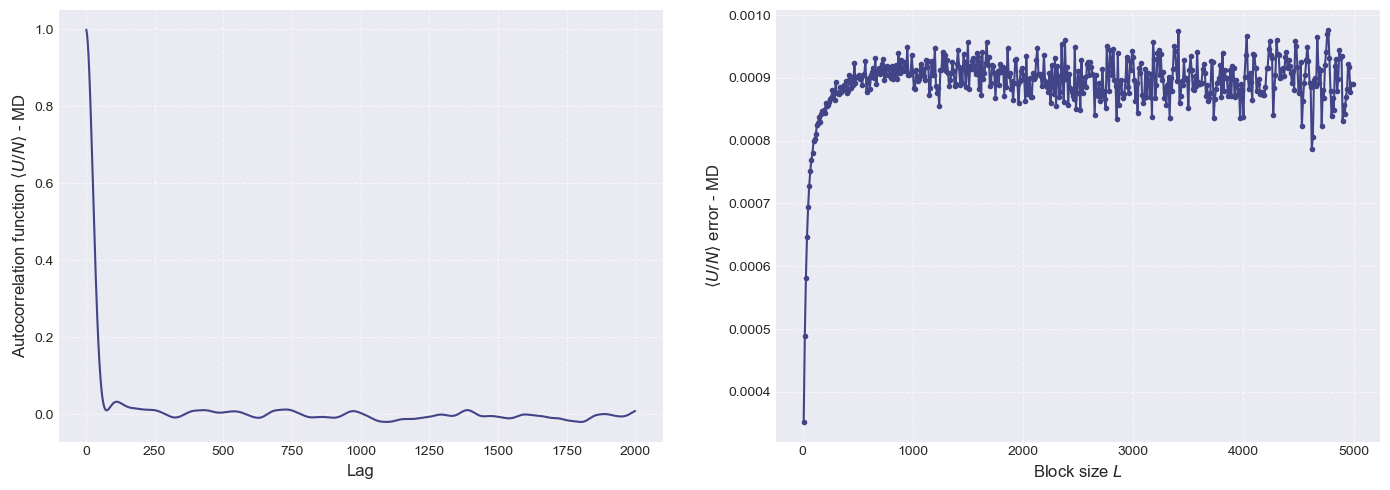

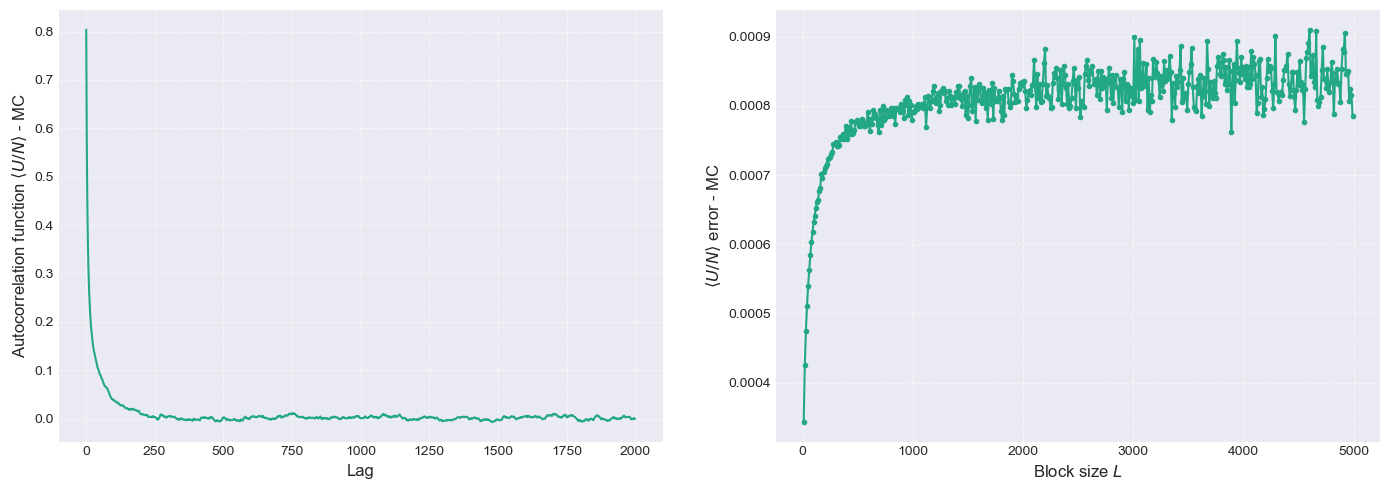

In [13]:
n_throws = 500000
max_lag = 2000
sizes = [10 * i for i in range(1, 500)] 
def autocorr(data, t):
    N = len(data)
    mean = np.mean(data)
    var = np.var(data)
    if var == 0:
        return 0
    sum_prod = np.sum((data[:N - t] - mean) * (data[t:] - mean))
    return sum_prod / ((N - t) * var)

def error(AV, AV2, n):
    if n == 0:
        return 0
    return math.sqrt((AV2[n] - AV[n]**2) / n)

def blockerror(data, N, L):
    ave = np.array([np.mean(data[i*L:(i+1)*L]) for i in range(N)])
    av2 = ave**2
    sum_prog = np.cumsum(ave) / np.arange(1, N+1)
    sum2_prog = np.cumsum(av2) / np.arange(1, N+1)
    return error(sum_prog, sum2_prog, N-1)
file_path_md = "MD_CODE/OUTPUT/CORRELATION/potential_energy.dat"
data_md = np.loadtxt(file_path_md, usecols=1, max_rows=n_throws, skiprows=1)

auto_md = [autocorr(data_md, t) for t in range(1, max_lag)]

valid_sizes_md = [L for L in sizes if n_throws // L >= 2]
errors_md = [blockerror(data_md, n_throws // L, L) for L in valid_sizes_md]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, max_lag), auto_md, color=color_MD)
axes[0].set_xlabel("Lag", fontsize=12)
axes[0].set_ylabel("Autocorrelation function $\\langle U/N \\rangle$ - MD",  fontsize=12)
axes[0].grid(True, alpha=0.6, linestyle='--')

axes[1].plot(valid_sizes_md, errors_md, marker='.', color=color_MD)
axes[1].set_xlabel("Block size $L$", fontsize=12)
axes[1].set_ylabel("$\\langle U/N \\rangle$ error - MD", fontsize=12)
axes[1].grid(True, alpha=0.6, linestyle='--')

plt.tight_layout(h_pad=3, w_pad=3)
plt.show()

file_path_mc = "MC_CODE/OUTPUT/CORRELATION/potential_energy.dat"
data_mc = np.loadtxt(file_path_mc, usecols=1, max_rows=n_throws, skiprows=1)

auto_mc = [autocorr(data_mc, t) for t in range(1, max_lag)]

valid_sizes_mc = [L for L in sizes if n_throws // L >= 2]
errors_mc = [blockerror(data_mc, n_throws // L, L) for L in valid_sizes_mc]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, max_lag), auto_mc, color=color_MC)
axes[0].set_xlabel("Lag", fontsize=12)
axes[0].set_ylabel("Autocorrelation function $\\langle U/N \\rangle$ - MC",  fontsize=12)
axes[0].grid(True, alpha=0.6, linestyle='--')

axes[1].plot(valid_sizes_mc, errors_mc, marker='.', color=color_MC)
axes[1].set_xlabel("Block size $L$", fontsize=12)
axes[1].set_ylabel("$\\langle U/N \\rangle$ error - MC", fontsize=12)
axes[1].grid(True, alpha=0.6, linestyle='--')

plt.tight_layout(h_pad=3, w_pad=3)
plt.show()

In [14]:
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

def plot_MD_vs_MC(file_MD, file_MC, ylabel_energy='Potential energy [eV]', ylabel_error='Statistical error [eV]'):

    x_MD, E_MD, err_MD = np.loadtxt(file_MD, usecols=(0, 2, 3), unpack=True, comments='#')
    x_MC, E_MC, err_MC = np.loadtxt(file_MC, usecols=(0, 2, 3), unpack=True, comments='#')
    
    fig, axs = plt.subplots(1, 2, figsize=(14, 6), dpi=100, sharex=True)
    
    axs[0].errorbar(
        x_MD, E_MD, yerr=err_MD,
        fmt='o', capsize=2, elinewidth=1.5,
        color=color_MD, alpha=0.6, label='MD'
    )
    axs[0].errorbar(
        x_MC, E_MC, yerr=err_MC,
        fmt='s', capsize=2, elinewidth=1.5,
        color=color_MC, alpha=0.6, label='MC'
    )
    axs[0].set_xlabel('Blocks')
    axs[0].set_ylabel(ylabel_energy)
    axs[0].legend()
    axs[0].grid(True, alpha=0.6, linestyle='--')
    
    axs[1].plot(
        x_MD, err_MD,
        '-', color=color_MD, alpha=0.8, label='MD'
    )
    axs[1].plot(
        x_MC, err_MC,
        '-', color=color_MC, alpha=0.8, label='MC'
    )
    axs[1].set_xlabel('Blocks')
    axs[1].set_ylabel(ylabel_error)
    axs[1].legend()
    axs[1].grid(True, alpha=0.6, linestyle='--')
    
    plt.tight_layout()
    plt.show()


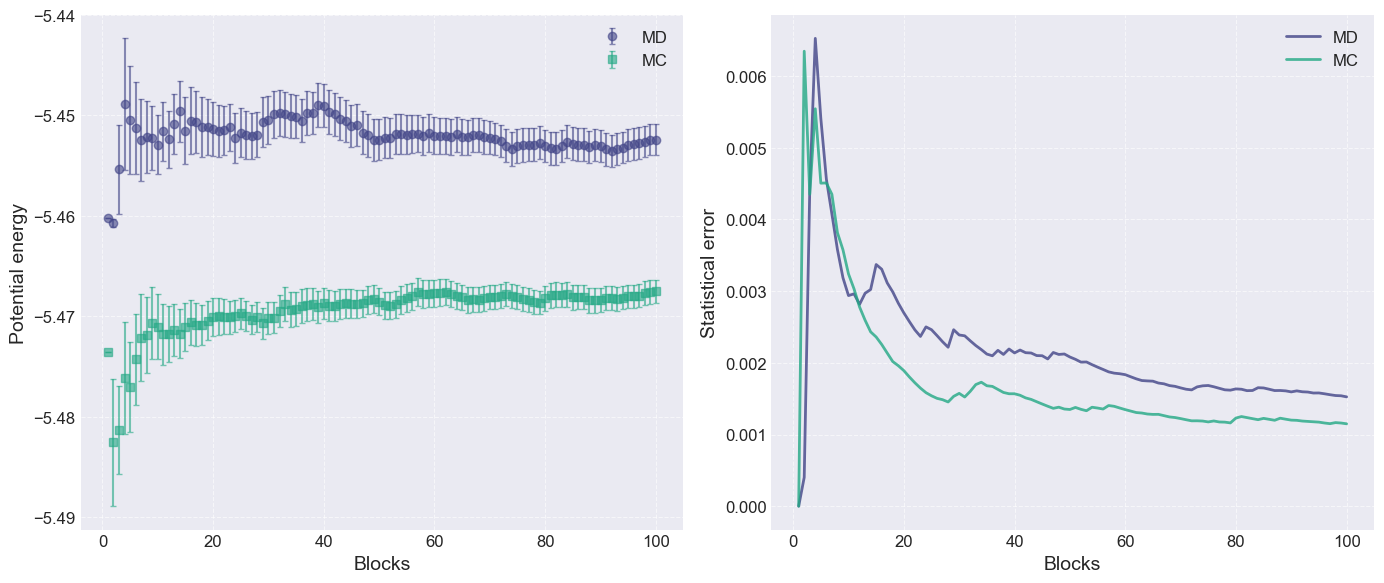

In [15]:
plot_MD_vs_MC("MD_CODE/OUTPUT/FIRST/potential_energy.dat", "MC_CODE/OUTPUT/FIRST/potential_energy.dat",'Potential energy', 'Statistical error')

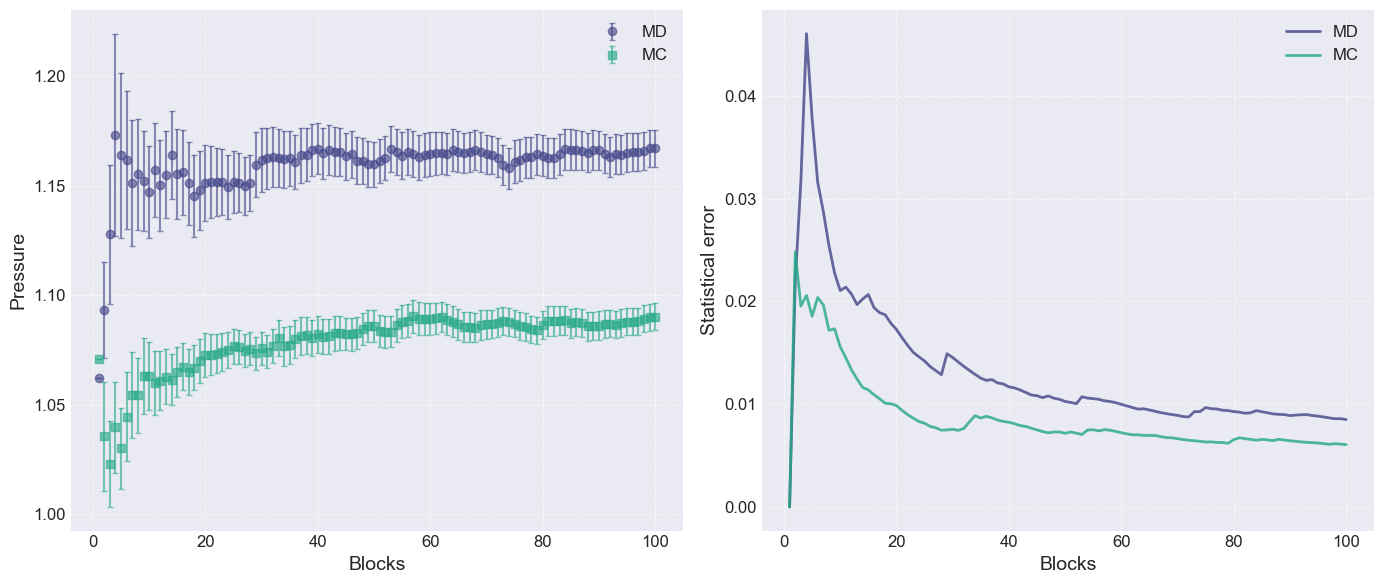

In [16]:
plot_MD_vs_MC("MD_CODE/OUTPUT/FIRST/pressure.dat", "MC_CODE/OUTPUT/FIRST/pressure.dat",'Pressure', 'Statistical error')

### Exercise 07.3

<span style="color:red">Include the calculation of the radial distribution function, $g(r)$, as a function of the radial distance $r$ among particles, with $r \in \left[ 0; L/2\right]$ inside the NSL simulator code</span>: average value of $g(r)$ in each block, final average value of $g(r)$ with statistical uncertainties in a separate file.

In [17]:
def plot_g_r_rmsd(file_md, file_mc, n_bins=100, color_MD=color_MD, color_MC=color_MC):

    data_md = np.loadtxt(file_md)
    data_mc = np.loadtxt(file_mc)

    n_blocks_md = data_md.shape[0] // n_bins
    n_blocks_mc = data_mc.shape[0] // n_bins
    n_blocks = min(n_blocks_md, n_blocks_mc)

    r_md, g_md, err_md = data_md[:, 0], data_md[:, 2], data_md[:, 3]
    r_mc, g_mc, err_mc = data_mc[:, 0], data_mc[:, 2], data_mc[:, 3]

    ymax = max(np.max(g_md + err_md), np.max(g_mc + err_mc))

    rmsd_blocks = []
    for i in range(n_blocks):
        s = i * n_bins
        e = s + n_bins
        diff2 = (g_md[s:e] - g_mc[s:e])**2
        rmsd_blocks.append(np.sqrt(np.mean(diff2)))
    rmsd_blocks = np.array(rmsd_blocks)

    fig, (ax_md, ax_mc, ax_rmsd) = plt.subplots(1, 3, figsize=(18, 6))

    for ax in (ax_md, ax_mc):
        ax.set_xlabel(r"$r$", fontsize=14)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_ylim(0, ymax * 1.1)
        ax.set_ylabel(r"$g(r)$", fontsize=14)

    s = (n_blocks - 1) * n_bins
    e = s + n_bins

    ax_md.errorbar(r_md[s:e], g_md[s:e], yerr=err_md[s:e],
                   fmt='o', ms=4, capsize=2, color=color_MD,
                   alpha=0.85, label="MD simulation")
    ax_mc.errorbar(r_mc[s:e], g_mc[s:e], yerr=err_mc[s:e],
                   fmt='o', ms=4, capsize=2, color=color_MC,
                   alpha=0.85, label="MC simulation")

    ax_md.legend(fontsize=12)
    ax_mc.legend(fontsize=12)

    ax_rmsd.plot(np.arange(1, n_blocks+1), rmsd_blocks, marker='o', color='tab:green')
    ax_rmsd.set_xlabel("Blocks", fontsize=14)
    ax_rmsd.set_ylabel("RMSD MD vs MC", fontsize=14)
    ax_rmsd.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

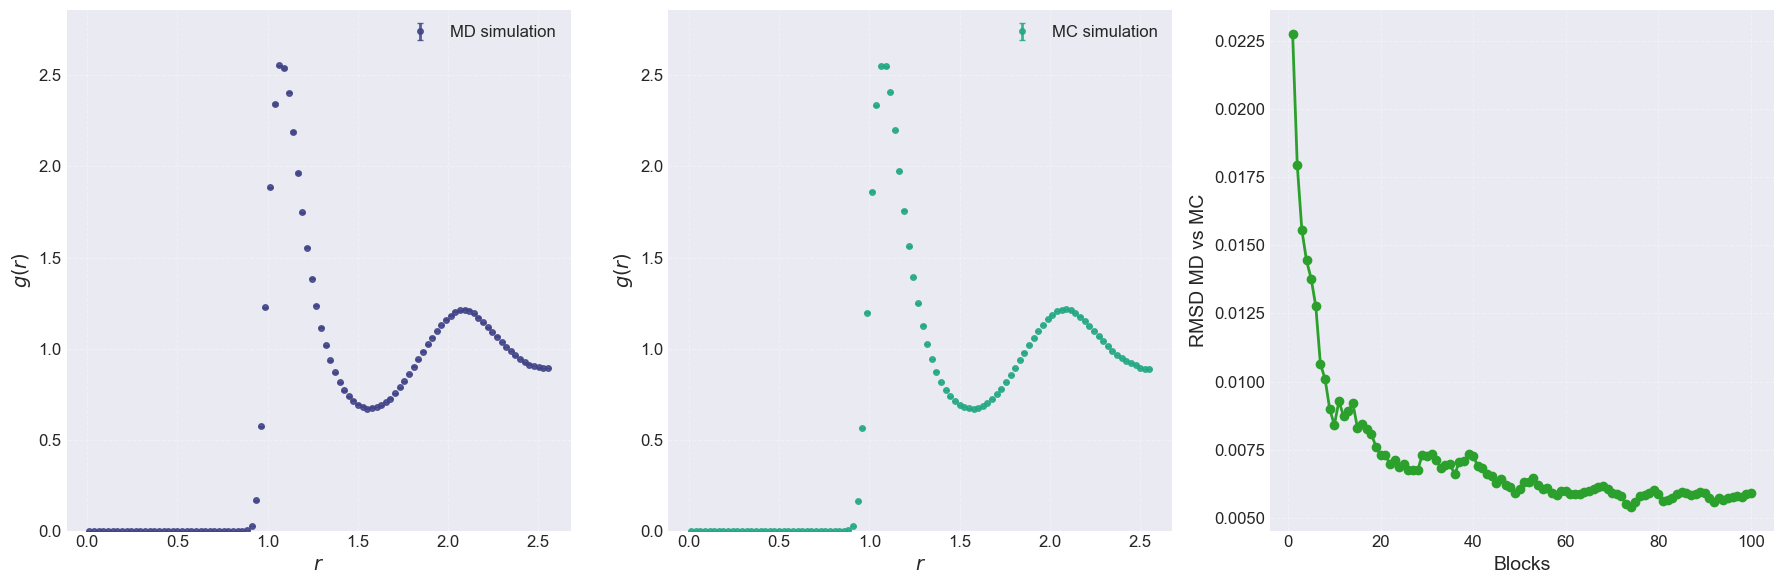

In [18]:
plot_g_r_rmsd(
    "MD_CODE/OUTPUT/FIRST/gofr.dat",
    "MC_CODE/OUTPUT/FIRST/gofr.dat",
    n_bins=100
)

### Supplementary activity ... just for your fun!
Note that he following **is not** part of the Numerical Exercise 7; if you had fun with exercises 7.* and you are courious, you could try to repeat exercises 7.2 and 7.4 in the following different thermodynamic conditions:
- solid phase: $\rho^\star = 1.1$, $T^\star = 0.8$ (cut-off radius: $r^\star_c = 2.2$)
- gas phase: $\rho^\star = 0.05$, $T^\star = 1.2$ (cut-off radius: $r^\star_c = 5.0$)

### Solid phase

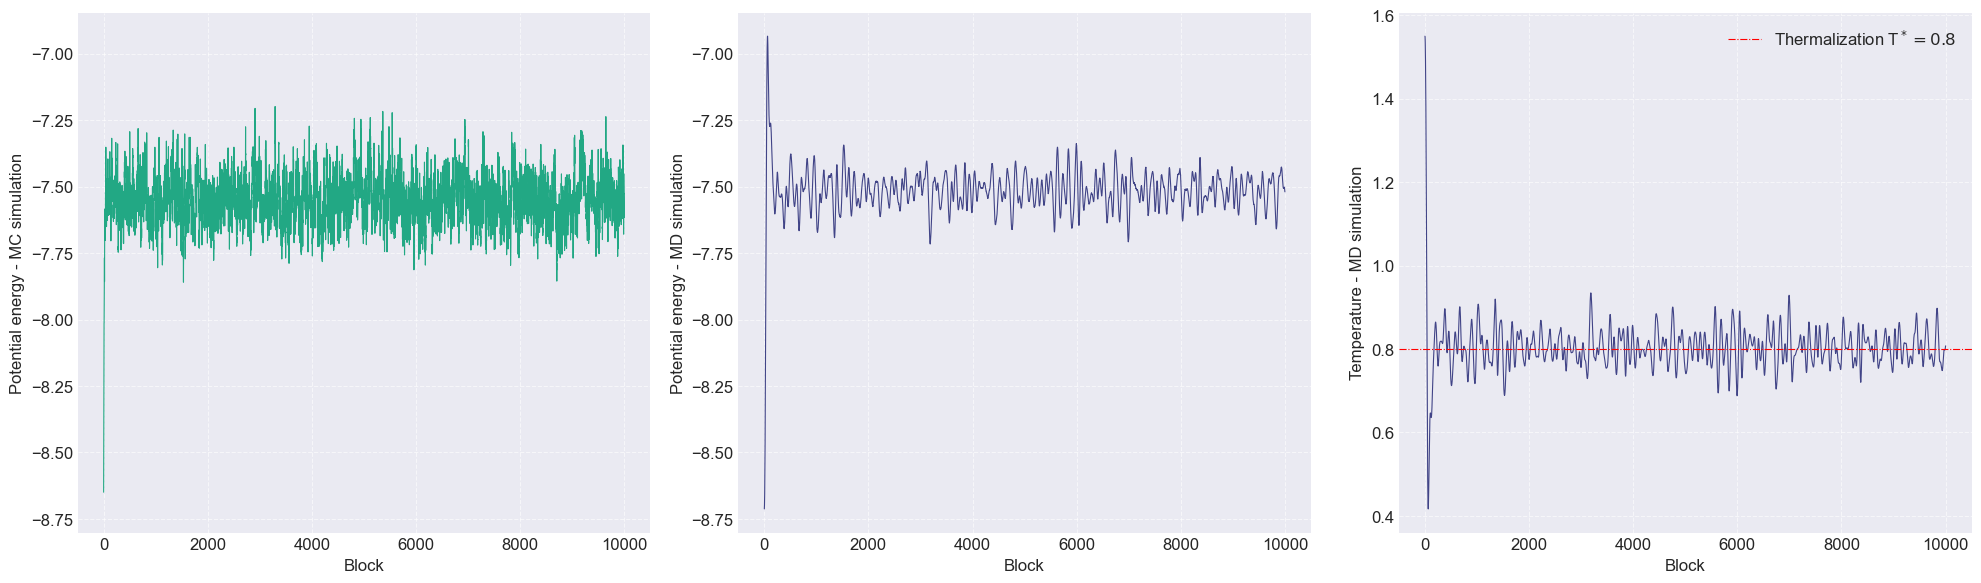

In [19]:
plot_thermalization(
    pot_file_MD='MD_CODE/OUTPUT/SOLID/THERMALIZATION/potential_energy.dat',
    pot_file_MC='MC_CODE/OUTPUT/SOLID/THERMALIZATION/potential_energy.dat',
    temp_file='MD_CODE/OUTPUT/SOLID/THERMALIZATION/temperature.dat',
    T_ref=0.8
)

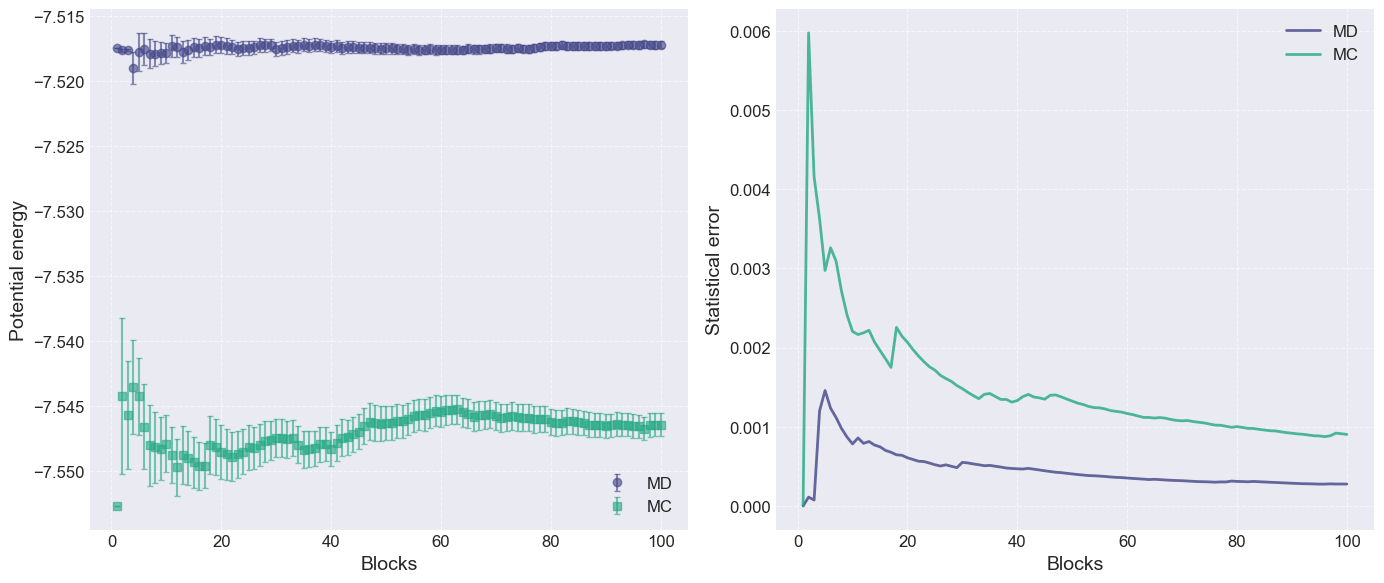

In [20]:
plot_MD_vs_MC("MD_CODE/OUTPUT/SOLID/potential_energy.dat", "MC_CODE/OUTPUT/SOLID/potential_energy.dat",'Potential energy', 'Statistical error')

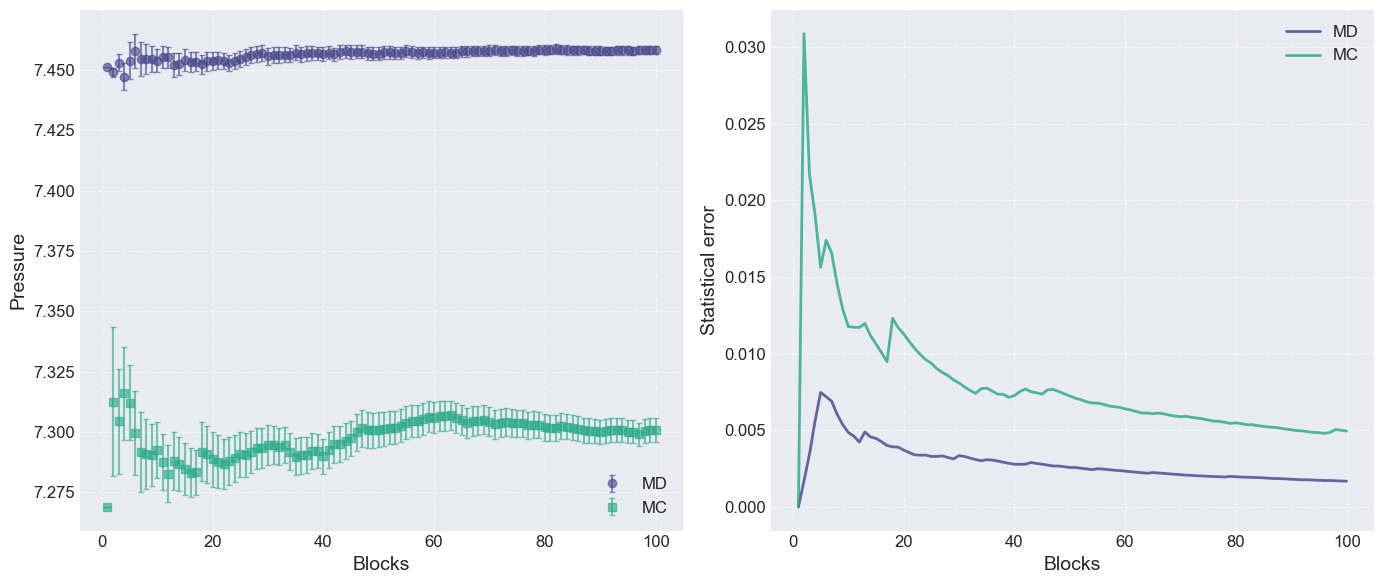

In [21]:
plot_MD_vs_MC("MD_CODE/OUTPUT/SOLID/pressure.dat", "MC_CODE/OUTPUT/SOLID/pressure.dat",'Pressure', 'Statistical error')

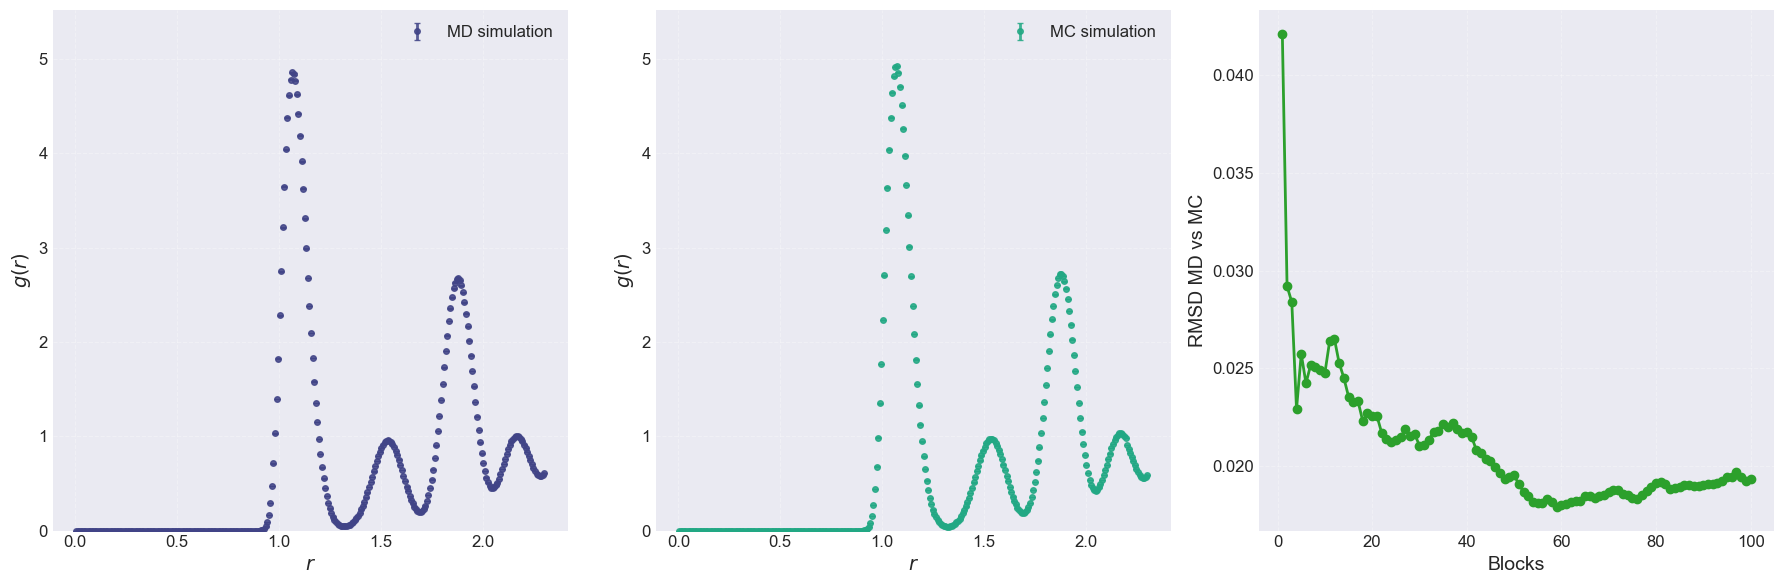

In [22]:
plot_g_r_rmsd(
    "MD_CODE/OUTPUT/SOLID/gofr.dat",
    "MC_CODE/OUTPUT/SOLID/gofr.dat",
    n_bins=300
)

### Liquid phase

Again using _halfside() for the MD code in the thermalization phase

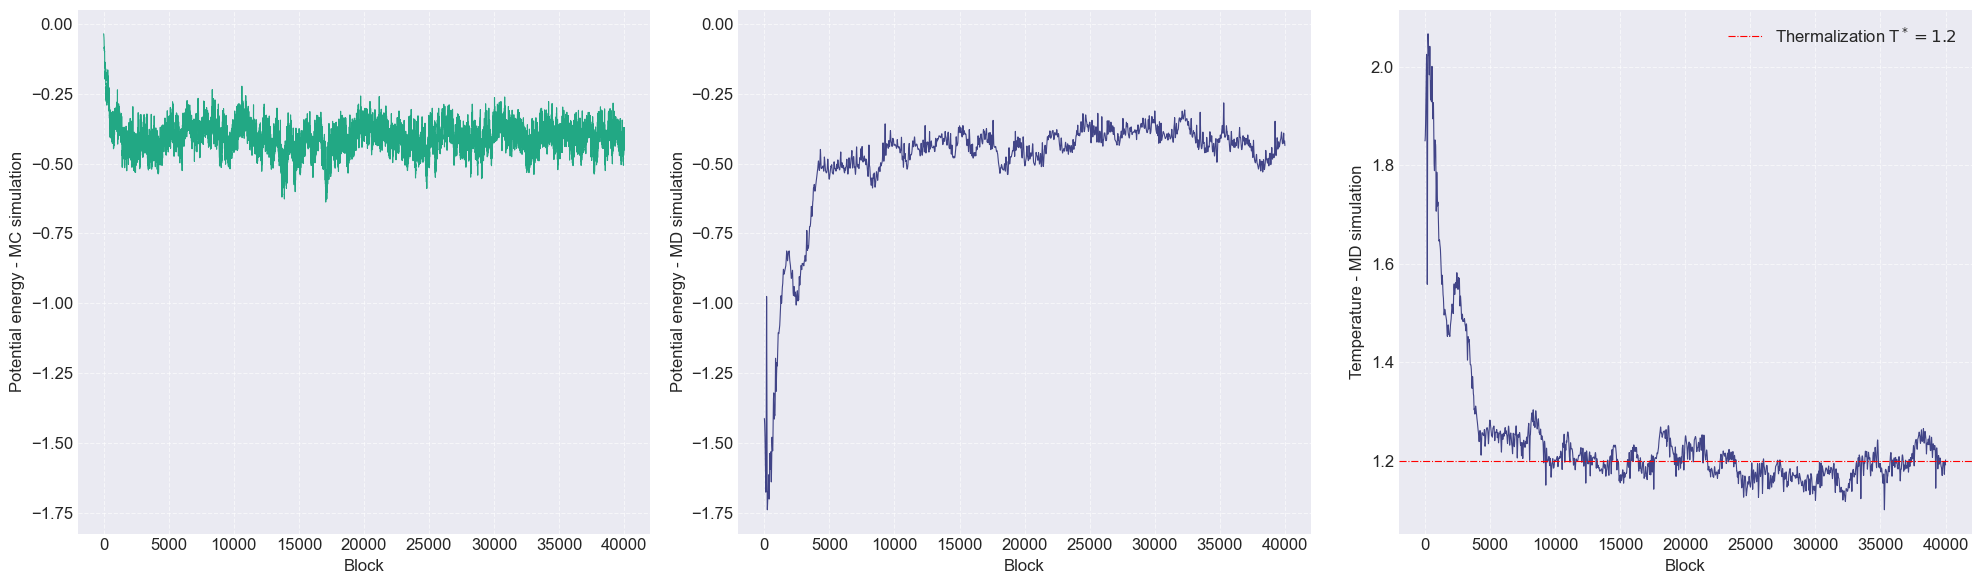

In [23]:
plot_thermalization(
    pot_file_MD='MD_CODE/OUTPUT/GAS/THERMALIZATION/potential_energy.dat',
    pot_file_MC='MC_CODE/OUTPUT/GAS/THERMALIZATION/potential_energy.dat',
    temp_file='MD_CODE/OUTPUT/GAS/THERMALIZATION/temperature.dat',
    T_ref=1.2
)

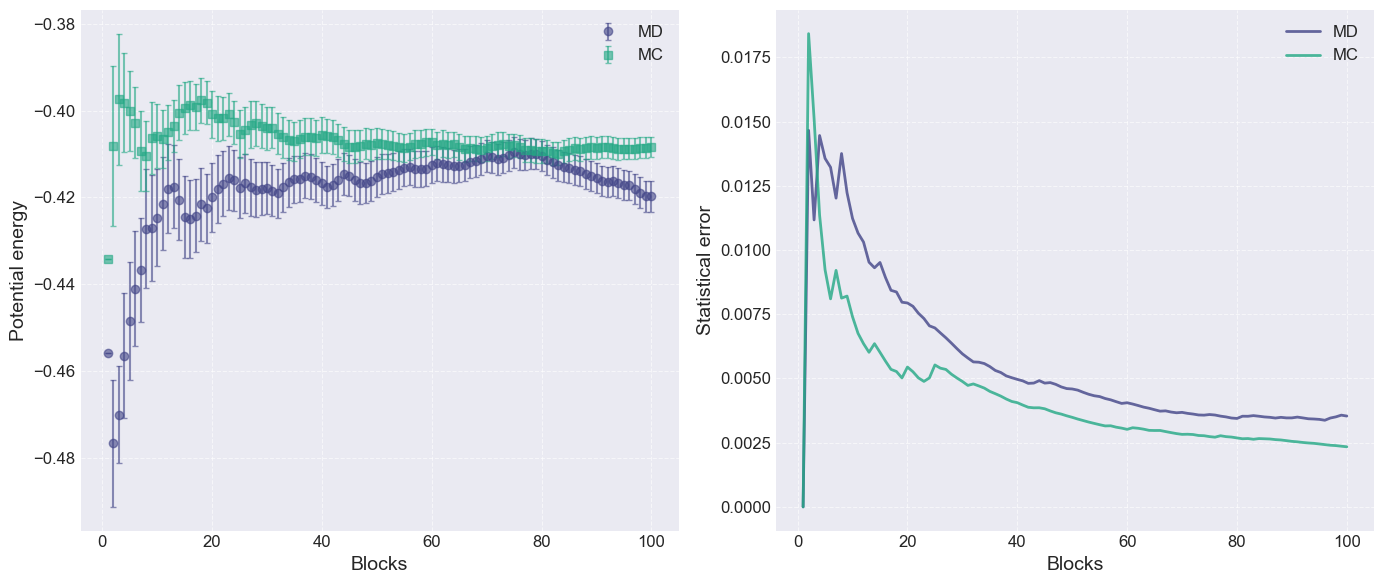

In [24]:
plot_MD_vs_MC("MD_CODE/OUTPUT/GAS/potential_energy.dat", "MC_CODE/OUTPUT/GAS/potential_energy.dat",'Potential energy', 'Statistical error')

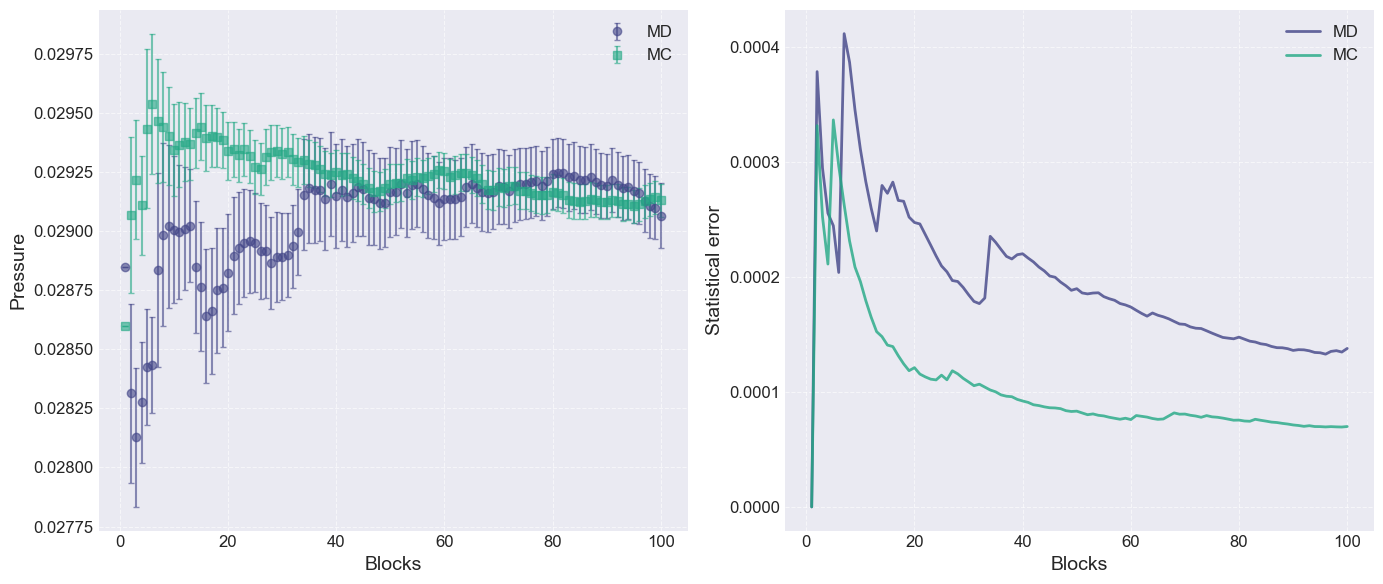

In [25]:
plot_MD_vs_MC("MD_CODE/OUTPUT/GAS/pressure.dat", "MC_CODE/OUTPUT/GAS/pressure.dat",'Pressure', 'Statistical error')

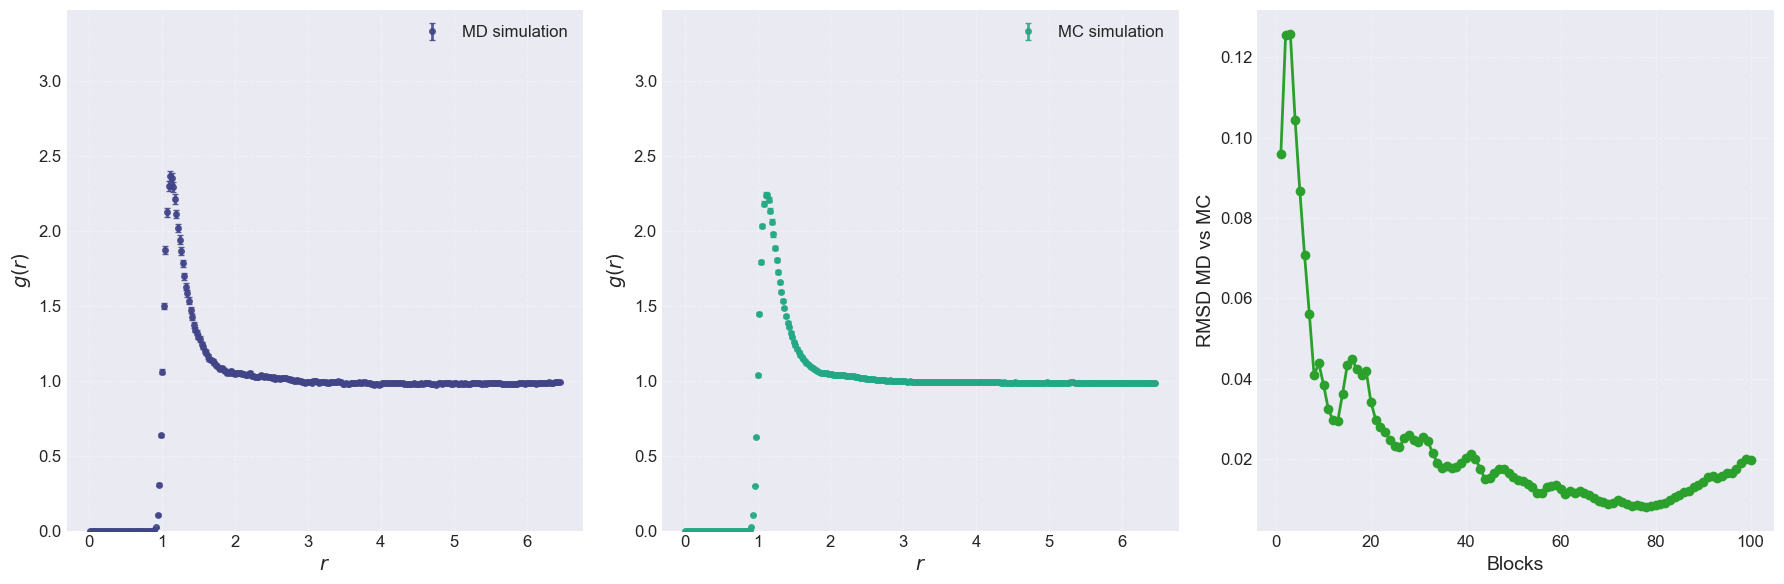

In [26]:
plot_g_r_rmsd(
    "MD_CODE/OUTPUT/GAS/gofr.dat",
    "MC_CODE/OUTPUT/GAS/gofr.dat",
    n_bins=300
)

In [45]:
colors = cm.coolwarm(np.linspace(0,1,4))
colors_multi = {'liquid': colors[0], 'solid': colors[1],'gas': colors[2]}

def plot_phases(liquid_MD, gas_MD, solid_MD,
                 ylabel_energy='Potential energy [eV]',
                 ylabel_error='Statistical error [eV]'):
    files_MD = {'liquid': liquid_MD, 'gas': gas_MD, 'solid': solid_MD}
    fig, axs = plt.subplots(1, 2, figsize=(16, 6), dpi=100, sharex=True)
    for phase in ['liquid', 'gas', 'solid']:
        x_MD, E_MD, err_MD = np.loadtxt(files_MD[phase], usecols=(0,2,3), unpack=True, comments='#')
        axs[0].errorbar(
            x_MD, E_MD, yerr=err_MD,
            fmt='o', capsize=2, elinewidth=1.5,
            color=colors_multi[phase], alpha=0.8, label=f'MD {phase}'
        )
        axs[1].plot(
            x_MD, err_MD,
            '-', color=colors_multi[phase], alpha=1, label=f'MD {phase}'
        )
    
    axs[0].set_xlabel('Blocks')
    axs[0].set_ylabel(ylabel_energy)
    axs[0].legend()
    axs[0].grid(True, alpha=0.6, linestyle='--')
    
    axs[1].set_xlabel('Blocks')
    axs[1].set_ylabel(ylabel_error)
    axs[1].legend()
    axs[1].grid(True, alpha=0.6, linestyle='--')
    
    plt.tight_layout()
    plt.show()


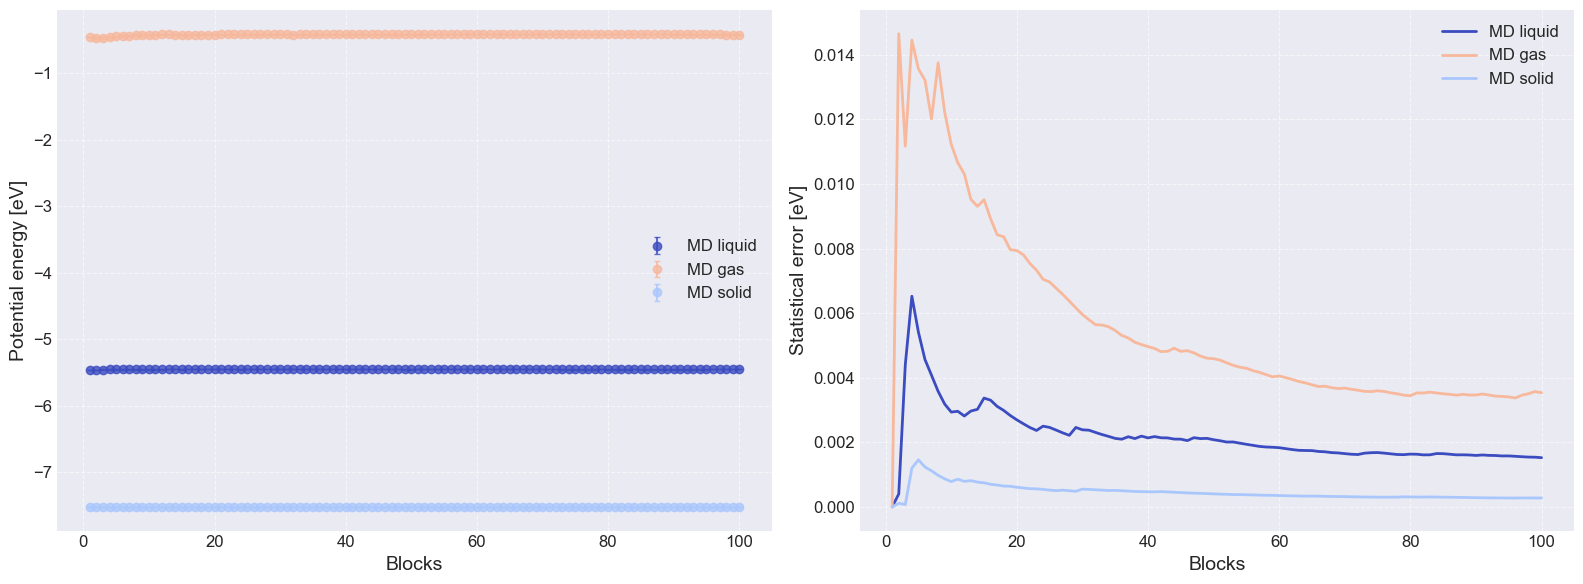

In [46]:
plot_phases(
    "MD_CODE/OUTPUT/FIRST/potential_energy.dat",
    "MD_CODE/OUTPUT/GAS/potential_energy.dat",
    "MD_CODE/OUTPUT/SOLID/potential_energy.dat"
)

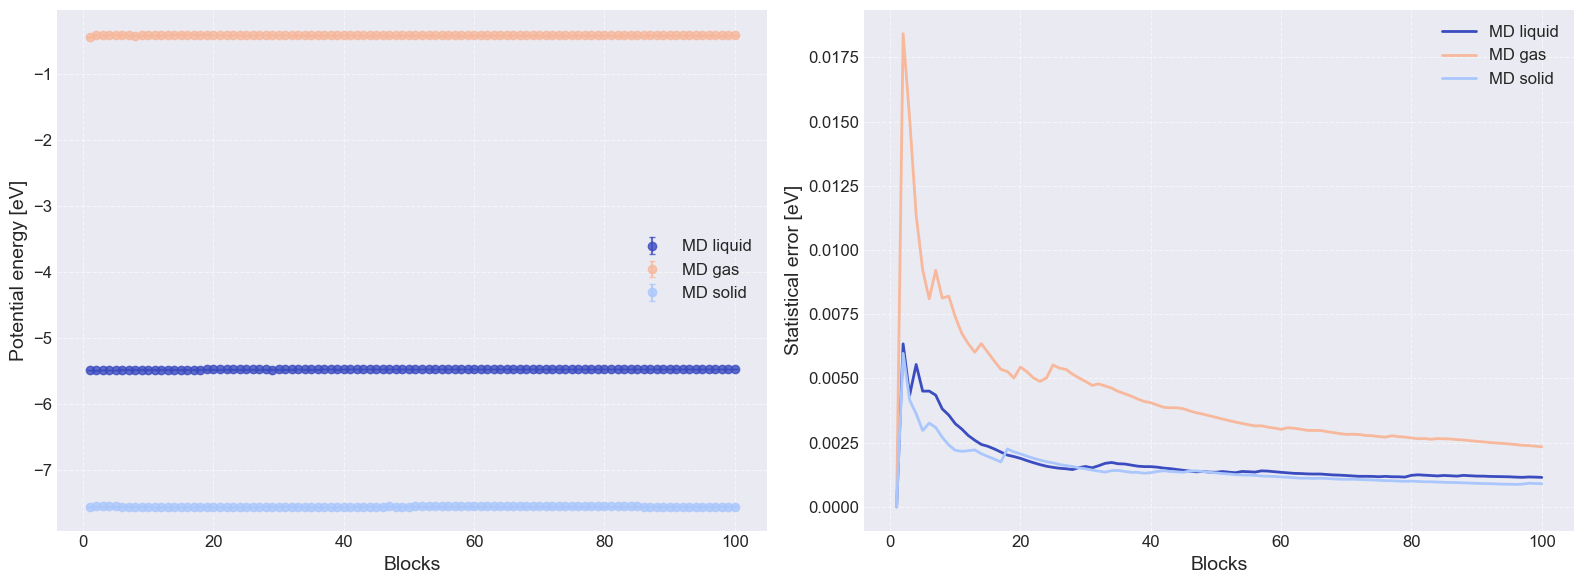

In [47]:
plot_phases(
    "MC_CODE/OUTPUT/FIRST/potential_energy.dat",
    "MC_CODE/OUTPUT/GAS/potential_energy.dat",
    "MC_CODE/OUTPUT/SOLID/potential_energy.dat"
)